In [ ]:
# Imports
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from percep import Perceptron
np.random.seed(42)

In [ ]:
# Generate a binary classification dataset
X, y = make_classification(n_samples=800, n_features=6, n_informative=4,
                           n_redundant=0, n_clusters_per_class=1, class_sep=1.5,
                           random_state=42)

# Train / test split
X_train, X_test, y_train_bin, y_test_bin = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Shapes:", X_train.shape, X_test.shape)
print("Class distribution train:", np.bincount(y_train_bin))

Shapes: (600, 6) (200, 6)
Class distribution train: [301 299]


In [ ]:
# scale features – helps convergence
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

In [ ]:
# Train & evaluate for different weight initializations (binary mode)
inits = ['zeroes', 'random', 'xavier']
results = []
for init in inits:
    p = Perceptron(X_train_s, y_train_bin, learning_rate=0.1,
                   weight_init_method=init, activation_method='binary')
    p.train(epochs=30, shuffle=True, verbose=False, early_stop=True)
    train_acc = p.accuracy()
    test_acc, mis = p.evaluate(X_test_s, y_test_bin)
    results.append((init, train_acc, test_acc, mis, p.error_history))
    print(f"Init={init:7s}  train_acc={train_acc:.3f}  test_acc={test_acc:.3f}  mis_test={mis}")

Init=zeroes   train_acc=0.950  test_acc=0.945  mis_test=11
Init=random   train_acc=0.915  test_acc=0.915  mis_test=17
Init=xavier   train_acc=0.940  test_acc=0.935  mis_test=13


In [ ]:
# Inspect one trained model
init_choice = 'xavier'
p_bin = Perceptron(X_train_s, y_train_bin, learning_rate=0.1,
                   weight_init_method=init_choice, activation_method='binary')
p_bin.train(epochs=30, shuffle=True, verbose=True, early_stop=True)
print("Weights (feat + bias):", p_bin.weights)
print("Train acc:", p_bin.accuracy())
print("Test acc / mis:", p_bin.evaluate(X_test_s, y_test_bin))
print("Error history:", p_bin.error_history)

Epoch 1/30 misclassified=73
Epoch 2/30 misclassified=54
Epoch 3/30 misclassified=44
Epoch 4/30 misclassified=44
Epoch 5/30 misclassified=48
Epoch 6/30 misclassified=41
Epoch 7/30 misclassified=32
Epoch 8/30 misclassified=51
Epoch 9/30 misclassified=46
Epoch 10/30 misclassified=45
Epoch 11/30 misclassified=41
Epoch 12/30 misclassified=40
Epoch 13/30 misclassified=48
Epoch 14/30 misclassified=43
Epoch 15/30 misclassified=39
Epoch 16/30 misclassified=43
Epoch 17/30 misclassified=44
Epoch 18/30 misclassified=45
Epoch 19/30 misclassified=47
Epoch 20/30 misclassified=47
Epoch 21/30 misclassified=50
Epoch 22/30 misclassified=45
Epoch 23/30 misclassified=35
Epoch 24/30 misclassified=44
Epoch 25/30 misclassified=40
Epoch 26/30 misclassified=41
Epoch 27/30 misclassified=48
Epoch 28/30 misclassified=40
Epoch 29/30 misclassified=46
Epoch 30/30 misclassified=43
Weights (feat + bias): [-0.04552293  1.47420742 -0.43245346 -0.14818463  0.19393721 -0.03105959
 -0.39719498]
Train acc: 0.9333333333333333

In [ ]:
# Confusion matrix & classification report (binary)
y_pred_test = p_bin.predict(X_test_s)
print("Confusion matrix:\n", confusion_matrix(y_test_bin, y_pred_test))
print(classification_report(y_test_bin, y_pred_test))

Confusion matrix:
 [[91  9]
 [ 5 95]]
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       100
           1       0.91      0.95      0.93       100

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.93       200
weighted avg       0.93      0.93      0.93       200



In [ ]:
# Bipolar mode (convert labels to {-1,1})
y_train_bip = np.where(y_train_bin == 1, 1, -1)
y_test_bip  = np.where(y_test_bin == 1, 1, -1)

p_bip = Perceptron(X_train_s, y_train_bip, learning_rate=0.1,
                   weight_init_method='xavier', activation_method='bipolar')
p_bip.train(epochs=30, shuffle=True, verbose=True, early_stop=True)
print("Bipolar train acc:", p_bip.accuracy())
print("Bipolar test acc / mis:", p_bip.evaluate(X_test_s, y_test_bip))

Epoch 1/30 misclassified=58
Epoch 2/30 misclassified=49
Epoch 3/30 misclassified=48
Epoch 4/30 misclassified=43
Epoch 5/30 misclassified=37
Epoch 6/30 misclassified=44
Epoch 7/30 misclassified=44
Epoch 8/30 misclassified=43
Epoch 9/30 misclassified=43
Epoch 10/30 misclassified=48
Epoch 11/30 misclassified=40
Epoch 12/30 misclassified=41
Epoch 13/30 misclassified=52
Epoch 14/30 misclassified=43
Epoch 15/30 misclassified=45
Epoch 16/30 misclassified=39
Epoch 17/30 misclassified=45
Epoch 18/30 misclassified=47
Epoch 19/30 misclassified=50
Epoch 20/30 misclassified=48
Epoch 21/30 misclassified=48
Epoch 22/30 misclassified=40
Epoch 23/30 misclassified=30
Epoch 24/30 misclassified=40
Epoch 25/30 misclassified=45
Epoch 26/30 misclassified=41
Epoch 27/30 misclassified=49
Epoch 28/30 misclassified=47
Epoch 29/30 misclassified=51
Epoch 30/30 misclassified=50
Bipolar train acc: 0.96
Bipolar test acc / mis: (np.float64(0.95), np.int64(10))


In [ ]:
# Compare binary vs bipolar on identical data / init style
comp_bin = Perceptron(X_train_s, y_train_bin, learning_rate=0.1,
                      weight_init_method='random', activation_method='binary').train(epochs=25)
comp_bip = Perceptron(X_train_s, y_train_bip, learning_rate=0.1,
                      weight_init_method='random', activation_method='bipolar').train(epochs=25)

print("Binary acc train:", comp_bin.accuracy(), "Bipolar acc train:", comp_bip.accuracy())
print("Binary test acc:", comp_bin.evaluate(X_test_s, y_test_bin)[0],
      "Bipolar test acc:", comp_bip.evaluate(X_test_s, y_test_bip)[0])

Binary acc train: 0.9466666666666667 Bipolar acc train: 0.915
Binary test acc: 0.925 Bipolar test acc: 0.905


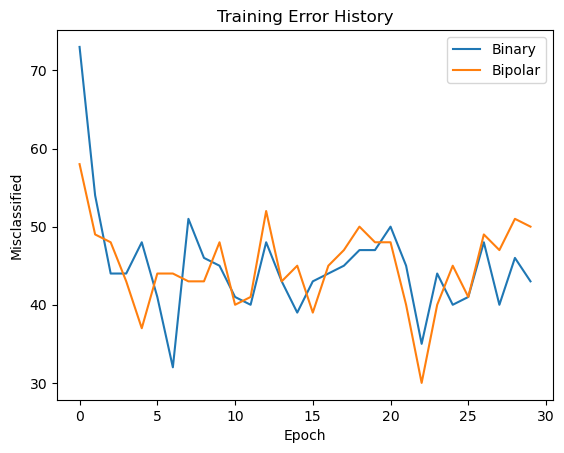

In [ ]:
# Plot error history
import matplotlib.pyplot as plt

plt.plot(p_bin.error_history, label='Binary')
plt.plot(p_bip.error_history, label='Bipolar')
plt.xlabel("Epoch")
plt.ylabel("Misclassified")
plt.legend()
plt.title("Training Error History")
plt.show()

In [ ]:
# Quick manual sample predictions
sample = X_test_s[:5]
print("Sample preds (binary):", p_bin.predict(sample))
print("Sample true  (binary):", y_test_bin[:5])
print("Sample preds (bipolar):", p_bip.predict(sample))
print("Sample true  (bipolar):", y_test_bip[:5])

Sample preds (binary): [0 0 1 0 0]
Sample true  (binary): [0 0 1 0 0]
Sample preds (bipolar): [-1 -1  1 -1 -1]
Sample true  (bipolar): [-1 -1  1 -1 -1]
